## Build a basic Chatbot with LangGraph(Graph API)

In [9]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages



In [10]:
class State(TypedDict):
    # Messages have the type "list". The add_messages function in the annotation defines how this state key should be updated (in this case, it appends messages to the list, reather than overwriting them)
    messages: Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [11]:
graph_builder

In [12]:
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen-qwq-32b")
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'Qwen QwQ 32B', 'status': 'deprecated', 'release_date': '2024-11-27', 'last_updated': '2024-11-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025869856F20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000258698570D0>, model_name='qwen-qwq-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [13]:
# Node Functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [14]:
graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#compile graph
graph=graph_builder.compile()

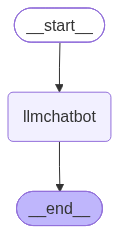

In [15]:
# Visualise the graph
from IPython.display import Image, display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
graph.invoke({"messages": ["Hi"]})

BadRequestError: Error code: 400 - {'error': {'message': 'The model `qwen-qwq-32b` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}